# Merged `IntegratedGradients` verifying it returns equal values to the non-merged IntegratedGradients

One `IntegratedGradients` class, three model types.

Unlike `Saliency`, this merge touches the maths' plumbing: the modality-agnostic
`LinearInterpolationPerturbator` is mixed with the modality base at runtime, and its
`perturb_tensor` now takes `processed_inputs` — embeddings `(1, l, d)` on the text side,
pixel values `(1, 3, H, W)` on the image side — instead of two separate classes with two
separate shape annotations. The interpolation itself is unchanged, so the outputs must match
the legacy classes bit for bit.

Note also that the merged perturbator no longer takes `inputs_embedder`: the text base class
holds it and the explainer fills it in, so the method never passes it down.

The last cell checks equality.

## Disable the runtime type checks (optional)

**Must run before anything imports `jaxtyping`** — the flag is read at import time, so this
has to be the first cell executed in a fresh kernel. Comment it out to get the shape checks
back; do that before believing any actual attribution numbers, since with the checks off a
shape bug surfaces as a downstream broadcast error or not at all.

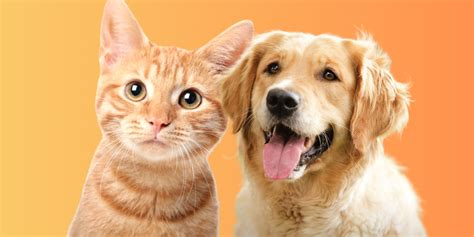

In [1]:
%matplotlib inline

import torch
from PIL import Image
from transformers import (
    AutoImageProcessor,
    AutoModelForCausalLM,
    AutoModelForImageClassification,
    AutoModelForSequenceClassification,
    AutoTokenizer,
)

from interpreto.attributions.methods.integrated_gradients import IntegratedGradients
from interpreto.attributions.methods.old_image_integrated_gradients import (
    ImageIntegratedGradients as LegacyImageIntegratedGradients,
)
from interpreto.attributions.methods.old_integrated_gradients import (
    IntegratedGradients as LegacyIntegratedGradients,
)
from interpreto.visualizations import plot_attributions, plot_image_attribution

sentence = "interpreto is nice"
image = Image.open("../fixtures/images/equal_cat_and_dog.jpg").convert("RGB")
image

## The three models

In [2]:
cls_model = AutoModelForSequenceClassification.from_pretrained("hf-internal-testing/tiny-random-bert")
cls_processor = AutoTokenizer.from_pretrained("hf-internal-testing/tiny-random-bert")

gen_model = AutoModelForCausalLM.from_pretrained("hf-internal-testing/tiny-random-gpt2")
gen_processor = AutoTokenizer.from_pretrained("hf-internal-testing/tiny-random-gpt2")

vit_model = AutoModelForImageClassification.from_pretrained("akahana/vit-base-cats-vs-dogs")
vit_processor = AutoImageProcessor.from_pretrained("akahana/vit-base-cats-vs-dogs")

Loading weights:   0%|          | 0/89 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: hf-internal-testing/tiny-random-bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
qa_outputs.bias                            | UNEXPECTED |  | 
qa_outputs.weight                          | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/64 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

## The three explainers

`n_perturbations` and `baseline` are left at their defaults (10 and `None`), which the legacy
text and image classes share, so the two paths interpolate over the same alphas.

In [3]:
cls_explainer = IntegratedGradients(
    cls_model,
    cls_processor,
)

gen_explainer = IntegratedGradients(
    gen_model,
    gen_processor,
)

vit_explainer = IntegratedGradients(
    vit_model,
    vit_processor,
)

legacy_cls_explainer = LegacyIntegratedGradients(cls_model, cls_processor)
legacy_gen_explainer = LegacyIntegratedGradients(gen_model, gen_processor)
legacy_vit_explainer = LegacyImageIntegratedGradients(vit_model, vit_processor)

# The default alphas are evenly spaced, so IntegratedGradients draws no random numbers; the
# seeds are only there to keep this cell interchangeable with the other merge notebooks.
torch.manual_seed(0)
legacy_cls_outputs = legacy_cls_explainer.explain(sentence)
torch.manual_seed(0)
legacy_gen_outputs = legacy_gen_explainer.explain(sentence, targets="right")
torch.manual_seed(0)
legacy_vit_outputs = legacy_vit_explainer.explain(image)

torch.manual_seed(0)
cls_outputs = cls_explainer.explain(sentence)
torch.manual_seed(0)
gen_outputs = gen_explainer.explain(sentence, targets="right")
torch.manual_seed(0)
vit_outputs = vit_explainer.explain(image)

## Checking that the new methods are equal to the old

We consider here that LegacyIntegratedGradients (on all task / modalities combination) is the
ground truth. We want to show that the merged IntegratedGradients method returns the same
AttributionOutput / ImageAttributionOutput as the ""Legacy""IntegratedGradients

In [4]:
def same(a, b):
    """Exact equality, counting NaN in the same position as a match."""
    return a.shape == b.shape and bool(((a == b) | (a.isnan() & b.isnan())).all())


for name, new, old in [
    ("cls", cls_outputs[0], legacy_cls_outputs[0]),
    ("gen", gen_outputs[0], legacy_gen_outputs[0]),
    ("vit", vit_outputs[0], legacy_vit_outputs[0]),
]:
    ok = same(new.attributions, old.attributions)
    print(f"{name}: {tuple(new.attributions.shape)}  {'identical' if ok else 'DIFFERENT'}")
    assert ok, f"{name}: merged attributions differ from legacy"

print("\nmerged IntegratedGradients reproduces the legacy attributions exactly")

cls: (1, 3)  identical
gen: (1, 4)  identical
vit: (1, 50176)  identical

merged IntegratedGradients reproduces the legacy attributions exactly


## Visualize

In [5]:
plot_attributions(cls_outputs[0])

In [6]:
plot_attributions(gen_outputs[0])

In [7]:
plot_attributions(legacy_gen_outputs[0])

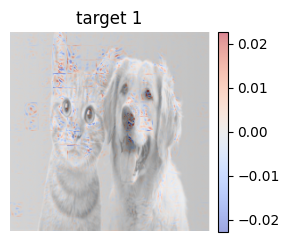

In [8]:
fig, axes = plot_image_attribution(vit_outputs, alpha=0.5)